<h1 style="text-align:center;">Reinforcement Learning : Stochastic Maze</h1>

Problem setup : Finding the optimal path on a hidden grid (exploration problem)

## Sommaire :

* [**1.Generation aleatory grid**](#0)

* [**2.MDP : Markov Decision Process**](#1)
    * [2.1. Q-learning](#1_1)
    * [2.2. SARSA](#1_2)


In [13]:
# Modules 
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm
from collections import deque
import random
from typing import Optional
import plotly.graph_objects as go

<a id='0'></a>
# 1. Generate aleatory grid :

In [14]:
def generate_aleatory_grid(n, complexity=0.2, seed=None):
    """
    Grille n×n avec 1 = mur, 0 = passage.
    Chemin aléatoire depuis colonne 0 jusqu'à colonne n-1.
    Complexité pour créer des fausses pistes

    Mouvements possibles à chaque pas :
      - droite : (row, col+1)
      - haut   : (row-1, col)  (même colonne)
      - bas    : (row+1, col)  (même colonne)

    """
    if seed is not None:
        np.random.seed(seed)

    grid = np.ones((n, n), dtype=int)

    # départ aléatoire colonne 0
    row = np.random.randint(0, n)
    col = 0
    grid[row, col] = 0
    col = 1
    grid[row, col] = 0

    # chemin jusqu'à la dernière colonne
    while col < n - 1:

        moves = ["R"]  # droite toujours possible tant qu'on n'est pas à la fin
        if row > 0:
            moves.append("U")  # up
        if row < n - 1:
            moves.append("D")  # down

        move = np.random.choice(moves)

        if move == "R":
            col += 1
        elif move == "U":
            row -= 1
        else:  # "D"
            row += 1

        grid[row, col] = 0

    # Rajout de la condition de complexité
    while (n**2 - np.sum(grid))/n**2 < complexity :
        col = np.random.randint(1, n-1)
        row = np.random.randint(1, n-1)
        grid[row, col] = 0

    return grid

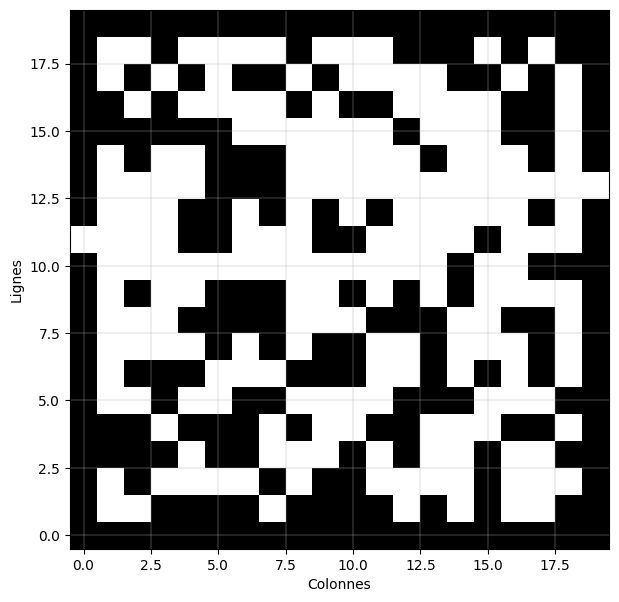

In [15]:
# --------- test + plot ----------
n = 20
grid = generate_aleatory_grid(n, complexity=0.5)

plt.figure(figsize=(7, 7))
plt.imshow(grid, cmap="gray_r", origin="lower")
plt.xlabel("Colonnes")
plt.ylabel("Lignes")
plt.grid(True, linewidth=0.3)
plt.show()

<a id='1'></a>
# 2. Markov Decision Process

<a id='1_1'></a>
## 2.1 Maze Escape with Q-Learning :

## Context
We consider a maze represented by an `n × n` grid:

- `0` = free cell (corridor)
- `1` = wall

The agent starts on the **first free cell of the left column**  
and the exit is the **first free cell of the right column**.

The environment is **deterministic** and **fully observable**:  
the full grid is known.

---

## MDP Formulation

We model the interaction as a Markov Decision Process:

$$
\text{MDP} = (S, A, P, R, \gamma)
$$

---

### States $(S)$

A state is simply the agent position:

$$
s = (i, j)
$$

where:

- $i$ = row index (vertical coordinate)
- $j$ = column index (horizontal coordinate)

The agent is located at cell `grid[i, j]`.

---

### Actions $(A)$

The available actions are:

$$
A = \{\text{Right}, \text{Left}, \text{Down}, \text{Up}\}
$$

Encoded as indices:

| Action | Index | Transition |
|--------|-------|-----------|
| Right  | 0 | $(i, j+1)$ |
| Left   | 1 | $(i, j-1)$ |
| Down   | 2 | $(i+1, j)$ |
| Up     | 3 | $(i-1, j)$ |

An action is **valid** only if:
- it stays inside the grid
- the destination cell is not a wall

---

### Transitions $(P)$

The environment is **deterministic**:

$$
P(s' \mid s,a) \in \{0,1\}
$$

- If the action is valid → probability 1
- Otherwise → action is not considered

---

### Rewards $(R)$

Reward shaping used in the implementation:

- `r = r_win` when reaching the exit
- `r = r_penality` otherwise (maybie 0 or negative)

---

### Discount Factor $(\gamma)$ ex $\sim 0.9$

- $\gamma \in [0,1)$
- Controls the importance of future rewards

---

## Value Functions

### State Value
$$
V(s) = \max_a Q(s,a)
$$

### Action Value
$$
Q(s,a) = R(s,a) + \gamma V(s')
$$

---

## Q-Learning (Model-Free RL)

We dont use transition probabilities explicitly.  
Instead, we learn the action-value function directly from experience.

### Update Rule

After observing a transition $(s,a,r,s')$:

$$
Q(s,a) \leftarrow Q(s,a) + \alpha
\Big(
r + \gamma \max_{a'} Q(s',a') - Q(s,a)
\Big)
$$

where:
- $\alpha$ = learning rate
- $\gamma$ = discount factor

---

## Exploration vs Exploitation

We use **ε-greedy** policy:

- with probability `ε` → random valid action
- with probability `1 − ε` → greedy action  
  $$ a = \arg\max_a Q(s,a) $$

---

## Episode Structure

Each episode:

1. Start at `start`
2. Repeat:
   - choose action (ε-greedy)
   - apply action
   - receive reward
   - update Q
3. Stop when:
   - exit reached
   - or max steps exceeded

---

## Output

The algorithm returns:

- `Q` : Q-table of shape `(n, n, 4)`
- `start` : starting cell
- `end` : exit cell

In [16]:
# ------------------------------------------------------------
# Constantes Actions
# ------------------------------------------------------------
A = ['R', 'L', 'D', 'U']
DIR = {0:(0,1), 1:(0,-1), 2:(1,0), 3:(-1,0)}  # (di,dj)

def find_start_end(grid):
    n = grid.shape[0]
    start_i = np.where(grid[:, 0] == 0)[0][0]
    end_i   = np.where(grid[:, n-1] == 0)[0][0]
    start = (int(start_i), 0)
    end   = (int(end_i), n-1)
    return start, end

def actions_valides(grid, i, j):
    n = grid.shape[0]
    idx = []
    if j < n-1 and grid[i, j+1] == 0: idx.append(0)  # R
    if j > 0   and grid[i, j-1] == 0: idx.append(1)  # L
    if i < n-1 and grid[i+1, j] == 0: idx.append(2)  # D
    if i > 0   and grid[i-1, j] == 0: idx.append(3)  # U
    return idx

def step_from_action(i, j, a_idx):
    di, dj = DIR[a_idx]
    return (i + di, j + dj)

# ------------------------------------------------------------
# Q-learning
# ------------------------------------------------------------
def MDP_Q_learning(grid, disc, eps, r, N, alpha=0.1, seed=None, max_steps=None):
    """
    Q-learning sur grille.
    - grid : (n,n) 0=libre, 1=mur
    - disc : gamma
    - eps  : epsilon-greedy
    - r    : [r_fail, r_win] (r_fail non utilisé si bloqué, comme dans ton code)
    - N    : nb épisodes
    - alpha: learning rate
    - seed : reproductibilité
    - max_steps : limite pas/épisode (None -> 10*n*n)
    """
    rng = np.random.default_rng(seed)
    n = grid.shape[0]

    start, end = find_start_end(grid)
    i_end, j_end = end

    Q = np.zeros((n, n, 4))

    if max_steps is None:
        max_steps = 10 * n * n

    for ep in range(N):
        s = start
        done = False

        for t in range(max_steps):
            i, j = s

            idx_ok = actions_valides(grid, i, j)
            if len(idx_ok) == 0:
                # coincé => échec 
                break

            # epsilon-greedy
            if rng.random() < eps:
                a_idx = rng.choice(idx_ok)
            else:
                qvals = Q[i, j, idx_ok]
                a_idx = idx_ok[int(np.argmax(qvals))]

            s_next = step_from_action(i, j, a_idx)
            ni, nj = s_next

            # reward + terminal
            if (ni == i_end) and (nj == j_end):
                reward = r[1]
                done = True
            else:
                reward = 0.0

            # target : target = r + gamma * max(Q_next)
            if done:
                target = reward
            else:
                idx_ok_next = actions_valides(grid, ni, nj)
                if len(idx_ok_next) == 0:
                    target = reward  # bloqué ensuite
                else:
                    target = reward + disc * np.max(Q[ni, nj, idx_ok_next])

            # update
            Q[i, j, a_idx] = Q[i, j, a_idx] + alpha * (target - Q[i, j, a_idx])

            s = s_next
            if done:
                break

    return Q, start, end

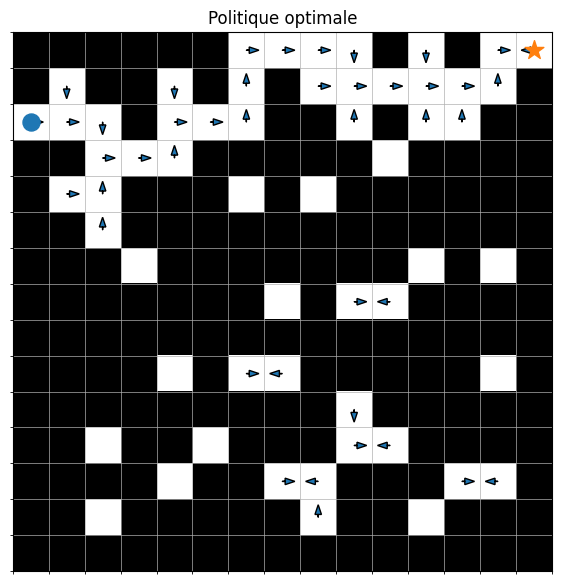

In [17]:
# Générer un labyrinthe
grid = generate_aleatory_grid(n=15, complexity=0.25)

# Apprendre Q
Q, start, end = MDP_Q_learning(
    grid=grid,
    disc=0.99,
    eps=0.2,
    r=[-10, 100],
    N=5000,
    alpha=0.1,
)

n = grid.shape[0]

fig, ax = plt.subplots(figsize=(7,7))

# grille
ax.imshow(grid, origin="upper", cmap="gray_r", vmin=0, vmax=1)


# flèches politique greedy
for i in range(n):
    for j in range(n):

        if grid[i, j] == 1:
            continue  # mur

        idx_ok = actions_valides(grid, i, j)
        if len(idx_ok) == 0:
            continue

        # argmax Q sur actions valides
        qvals = Q[i, j, idx_ok]
        a_star = idx_ok[int(np.argmax(qvals))]

        di, dj = DIR[a_star]

        ax.arrow(
            j, i,
            0.35 * dj,
            0.35 * di,
            head_width=0.18,
            length_includes_head=True
        )

# start / end
ax.scatter(start[1], start[0], s=150, marker="o")
ax.scatter(end[1], end[0], s=200, marker="*")

# grille visuelle
ax.set_xticks(np.arange(-.5, n, 1), minor=True)
ax.set_yticks(np.arange(-.5, n, 1), minor=True)
ax.grid(which="minor", linewidth=0.5)
ax.set_xticks([])
ax.set_yticks([])

ax.set_title("Politique optimale")
plt.show()

## Visualisation : Evolution de Q

In [18]:
# ------------------------------------------------------------
# On reprend mon algo en rajoutant des snaps
# ------------------------------------------------------------
def MDP_Q_learning_with_snaps(grid, disc, eps, r, N, alpha=0.1, seed=None, max_steps=None,
                              save_every=50):
    rng = np.random.default_rng(seed)
    n = grid.shape[0]

    start, end = find_start_end(grid)
    i_end, j_end = end

    Q = np.zeros((n, n, 4))

    if max_steps is None:
        max_steps = 10 * n * n

    Q_snaps = []
    ep_snaps = []

    for ep in range(N):
        s = start
        done = False

        for t in range(max_steps):
            i, j = s

            idx_ok = actions_valides(grid, i, j)
            if len(idx_ok) == 0:
                break

            # epsilon-greedy
            if rng.random() < eps:
                a_idx = rng.choice(idx_ok)
            else:
                qvals = Q[i, j, idx_ok]
                a_idx = idx_ok[int(np.argmax(qvals))]

            s_next = step_from_action(i, j, a_idx)
            ni, nj = s_next

            # reward + terminal
            if (ni == i_end) and (nj == j_end):
                reward = r[1]
                done = True
            else:
                reward = 0.0

            # target
            if done:
                target = reward
            else:
                idx_ok_next = actions_valides(grid, ni, nj)
                if len(idx_ok_next) == 0:
                    target = reward
                else:
                    target = reward + disc * np.max(Q[ni, nj, idx_ok_next])

            # update
            Q[i, j, a_idx] = Q[i, j, a_idx] + alpha * (target - Q[i, j, a_idx])

            s = s_next
            if done:
                break

        if save_every is not None and (ep % save_every == 0):
            Q_snaps.append(Q.copy())
            ep_snaps.append(ep)

    return Q, start, end, Q_snaps, ep_snaps

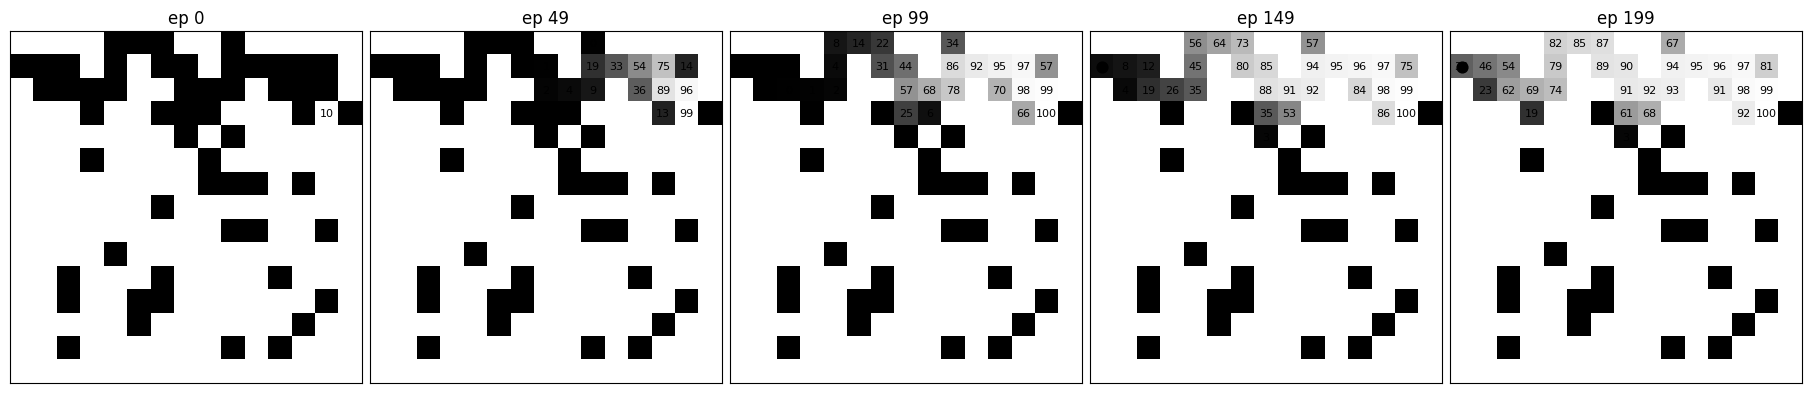

In [19]:
# ---- Plot évolution de Q ----

def plot_Q_5snaps(grid, disc, eps, r, N, alpha=0.1, seed=None, max_steps=None):

    Q, start, end, Q_snaps, ep_snaps = MDP_Q_learning_with_snaps(
        grid=grid, disc=disc, eps=eps, r=r, N=N,
        alpha=alpha, seed=seed, max_steps=max_steps, save_every=1
    )

    targets = [0, int(0.25*(N-1)), int(0.50*(N-1)), int(0.75*(N-1)), N-1]

    n = grid.shape[0]
    fig, axes = plt.subplots(1, 5, figsize=(18, 4), constrained_layout=True)

    for ax, ep in zip(axes, targets):
        Qe = Q_snaps[ep]
        V  = np.max(Qe, axis=2)

        # murs -> NaN pour blanc
        V_plot = V.astype(float)
        V_plot[grid == 1] = np.nan

        ax.imshow(V_plot, origin="upper", cmap="gray")

        # valeurs numériques
        for i in range(n):
            for j in range(n):
                if grid[i, j] == 1:
                    continue
                ax.text(j, i, f"{V[i,j]:.0f}",
                        ha="center", va="center", fontsize=8, color="black")

        # start / end
        ax.scatter(start[1], start[0], s=60, marker="o", color="black")
        ax.scatter(end[1], end[0], s=80, marker="*", color="black")

        ax.set_title(f"ep {ep}")
        ax.set_xticks([]); ax.set_yticks([])

    plt.show()

# ---- usage ----
grid = generate_aleatory_grid(n=15, complexity=0.25)
plot_Q_5snaps(grid, disc=0.99, eps=0.2, r=[-10,100], N=200, alpha=0.1, seed=0)

<a id='1_2'></a>
## 2.2 SARSA :


## General Idea

SARSA is a **tabular Reinforcement Learning** algorithm that learns a function:

$$
Q(s,a) = \text{expected value of taking action } a \text{ in state } s
$$


---


## Logical Loop

At each step we observe a quintuple:

$$
(s, a, r, s', a')
$$

Hence the name **SARSA**:

- **S** : State $s$
- **A** : Action $a$
- **R** : Reward $r$
- **S** : Next State $s'$
- **A** : Next Action $a'$

---

## Update Rule

$$
Q(s,a) \leftarrow Q(s,a) + \alpha \Big[ r + \gamma Q(s',a') - Q(s,a) \Big]
$$

where:

- $\alpha \in (0,1)$ : learning rate  
- $\gamma \in (0,1)$ : discount factor  
- $a'$ : **the action actually chosen** in $s'$ (usually via $\varepsilon$-greedy)

---

## Exploration Policy (ε-greedy)

At each state $s$:

$$
a =
\begin{cases}
\arg\max_a Q(s,a) & \text{with prob. } 1-\varepsilon \\
\text{random action} & \text{with prob. } \varepsilon
\end{cases}
$$

Unlike Q-Learning, SARSA **incorporates this exploration directly into the update**.



In [20]:
# ------------------------------------------------------------
# SARSA
# ------------------------------------------------------------
def SARSA(grid, disc, eps, r, N, alpha=0.1, seed=None, max_steps=None):
    """
    SARSA sur grille.
    - grid : (n,n) 0=libre, 1=mur
    - disc : gamma
    - eps  : epsilon-greedy
    - r    : [r_fail, r_win] (r_fail non utilisé si bloqué, comme dans ton code)
    - N    : nb épisodes
    - alpha: learning rate
    - seed : reproductibilité
    - max_steps : limite pas/épisode (None -> 10*n*n)
    """
    rng = np.random.default_rng(seed)
    n = grid.shape[0]

    start, end = find_start_end(grid)
    i_end, j_end = end

    Q = np.zeros((n, n, 4))

    if max_steps is None:
        max_steps = 10 * n * n

    for ep in range(N):
        s = start
        i, j = s

        idx_ok = actions_valides(grid, i, j)
        if len(idx_ok) == 0:
            continue

        # --- Un seul tirage de epsilon pour décider la politique
        if rng.random() < eps:
            a_idx = rng.choice(idx_ok)
        else:
            qvals = Q[i, j, idx_ok]
            a_idx = idx_ok[int(np.argmax(qvals))]

        for t in range(max_steps):
            i, j = s
            s_next = step_from_action(i, j, a_idx)
            ni, nj = s_next

            # reward + terminal
            if (ni == i_end) and (nj == j_end):
                reward = r[1]
                done = True
            else:
                reward = 0.0
                done = False

            if done:
                target = reward
                Q[i, j, a_idx] += alpha * (target - Q[i, j, a_idx])
                break

            idx_ok_next = actions_valides(grid, ni, nj)
            if len(idx_ok_next) == 0:
                target = reward
                Q[i, j, a_idx] += alpha * (target - Q[i, j, a_idx])
                break

            # --- On réutilise le tirage de espilon pour savoir quelle valeur on rentre dans Q
            if rng.random() < eps:
                a_next = rng.choice(idx_ok_next)
            else:
                qvals_next = Q[ni, nj, idx_ok_next]
                a_next = idx_ok_next[int(np.argmax(qvals_next))]

            target = reward + disc * Q[ni, nj, a_next]

            # update
            Q[i, j, a_idx] += alpha * (target - Q[i, j, a_idx])

            # avance : (s,a) <- (s_next, a_next)
            s = s_next
            a_idx = a_next

    return Q, start, end


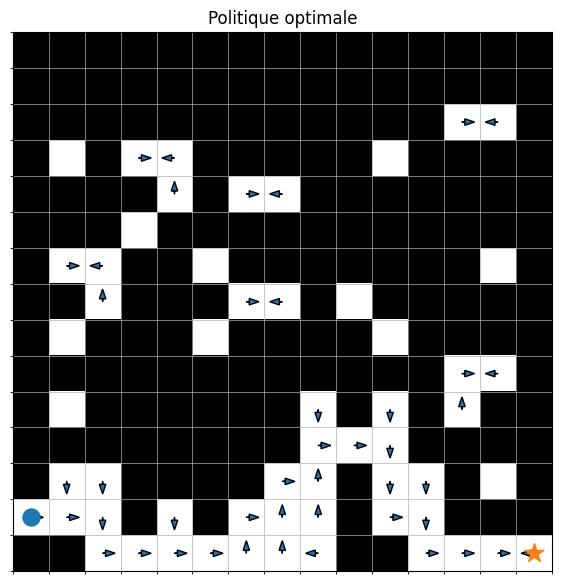

In [21]:
# Générer un labyrinthe
grid = generate_aleatory_grid(n=15, complexity=0.25)

# Apprendre Q
Q, start, end = SARSA(
    grid=grid,
    disc=0.99,
    eps=0.2,
    r=[-10, 100],
    N=5000,
    alpha=0.1,
)

n = grid.shape[0]

fig, ax = plt.subplots(figsize=(7,7))

# grille
ax.imshow(grid, origin="upper", cmap="gray_r", vmin=0, vmax=1)


# flèches politique greedy
for i in range(n):
    for j in range(n):

        if grid[i, j] == 1:
            continue  # mur

        idx_ok = actions_valides(grid, i, j)
        if len(idx_ok) == 0:
            continue

        # argmax Q sur actions valides
        qvals = Q[i, j, idx_ok]
        a_star = idx_ok[int(np.argmax(qvals))]

        di, dj = DIR[a_star]

        ax.arrow(
            j, i,
            0.35 * dj,
            0.35 * di,
            head_width=0.18,
            length_includes_head=True
        )

# start / end
ax.scatter(start[1], start[0], s=150, marker="o")
ax.scatter(end[1], end[0], s=200, marker="*")

# grille visuelle
ax.set_xticks(np.arange(-.5, n, 1), minor=True)
ax.set_yticks(np.arange(-.5, n, 1), minor=True)
ax.grid(which="minor", linewidth=0.5)
ax.set_xticks([])
ax.set_yticks([])

ax.set_title("Politique optimale")
plt.show()

## Visualisation : Evolution de Q

In [22]:
# ------------------------------------------------------------
# SARSA with snaps for visualisation
# ------------------------------------------------------------
def SARSA_with_snaps(grid, disc, eps, r, N, alpha=0.1, seed=None, max_steps=None, save_every=50):

    rng = np.random.default_rng(seed)
    n = grid.shape[0]

    start, end = find_start_end(grid)
    i_end, j_end = end

    Q = np.zeros((n, n, 4))

    if max_steps is None:
        max_steps = 10 * n * n

    Q_snaps = []
    ep_snaps = []

    for ep in range(N):
        s = start
        i, j = s

        idx_ok = actions_valides(grid, i, j)
        if len(idx_ok) == 0:
            continue

        # --- Un seul tirage de epsilon pour décider la politique
        if rng.random() < eps:
            a_idx = rng.choice(idx_ok)
        else:
            qvals = Q[i, j, idx_ok]
            a_idx = idx_ok[int(np.argmax(qvals))]

        for t in range(max_steps):
            i, j = s
            s_next = step_from_action(i, j, a_idx)
            ni, nj = s_next

            # reward + terminal
            if (ni == i_end) and (nj == j_end):
                reward = r[1]
                done = True
            else:
                reward = 0.0
                done = False

            if done:
                target = reward
                Q[i, j, a_idx] += alpha * (target - Q[i, j, a_idx])
                break

            idx_ok_next = actions_valides(grid, ni, nj)
            if len(idx_ok_next) == 0:
                target = reward
                Q[i, j, a_idx] += alpha * (target - Q[i, j, a_idx])
                break

            # --- On réutilise le tirage de espilon pour savoir quelle valeur on rentre dans Q
            if rng.random() < eps:
                a_next = rng.choice(idx_ok_next)
            else:
                qvals_next = Q[ni, nj, idx_ok_next]
                a_next = idx_ok_next[int(np.argmax(qvals_next))]

            target = reward + disc * Q[ni, nj, a_next]

            # update
            Q[i, j, a_idx] += alpha * (target - Q[i, j, a_idx])

            # avance : (s,a) <- (s_next, a_next)
            s = s_next
            a_idx = a_next

        if save_every is not None and (ep % save_every == 0):
            Q_snaps.append(Q.copy())
            ep_snaps.append(ep)


    return Q, start, end, Q_snaps, ep_snaps

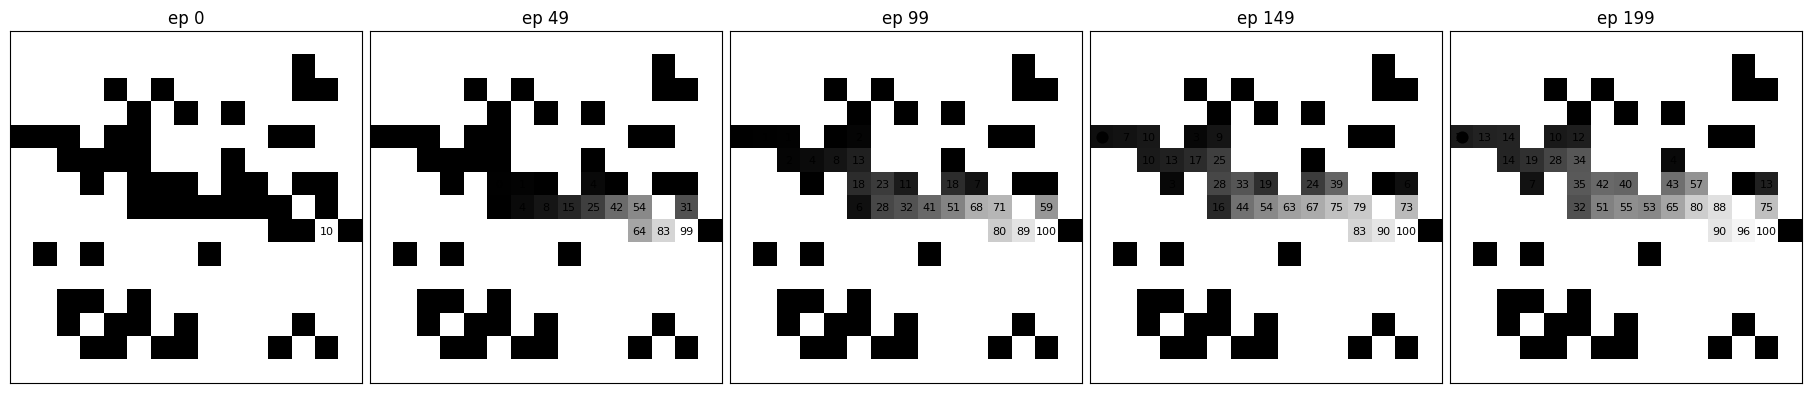

In [23]:
# ---- Plot évolution de Q ----

def plot_Q_5snaps(grid, disc, eps, r, N, alpha=0.1, seed=None, max_steps=None):

    Q, start, end, Q_snaps, ep_snaps = SARSA_with_snaps(
        grid=grid, disc=disc, eps=eps, r=r, N=N,
        alpha=alpha, seed=seed, max_steps=max_steps, save_every=1
    )

    targets = [0, int(0.25*(N-1)), int(0.50*(N-1)), int(0.75*(N-1)), N-1]

    n = grid.shape[0]
    fig, axes = plt.subplots(1, 5, figsize=(18, 4), constrained_layout=True)

    for ax, ep in zip(axes, targets):
        Qe = Q_snaps[ep]
        V  = np.max(Qe, axis=2)

        # murs -> NaN pour blanc
        V_plot = V.astype(float)
        V_plot[grid == 1] = np.nan

        ax.imshow(V_plot, origin="upper", cmap="gray")

        # valeurs numériques
        for i in range(n):
            for j in range(n):
                if grid[i, j] == 1:
                    continue
                ax.text(j, i, f"{V[i,j]:.0f}",
                        ha="center", va="center", fontsize=8, color="black")

        # start / end
        ax.scatter(start[1], start[0], s=60, marker="o", color="black")
        ax.scatter(end[1], end[0], s=80, marker="*", color="black")

        ax.set_title(f"ep {ep}")
        ax.set_xticks([]); ax.set_yticks([])

    plt.show()

# ---- usage ----
grid = generate_aleatory_grid(n=15, complexity=0.25)
plot_Q_5snaps(grid, disc=0.99, eps=0.2, r=[-10,100], N=200, alpha=0.1, seed=0)